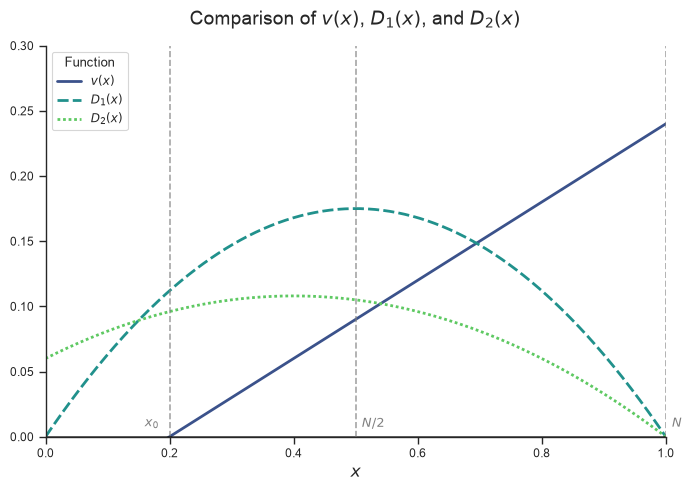

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define Parameters
N = 100            # Upper bound for x
p1 = 0.7  # Scaling factor/price
p2 = 1-p1
x0 = 20/N            # A value between 0 and N
x = np.linspace(0, 1, 500)

# 2. Define functions
v = p2 * (x - x0)
D1 = p1 * x*(1-x)
D2 = p2 * (x+x0)*(1-x)

# 3. Prepare data for Seaborn
data = pd.DataFrame({
    'x': x,
    '$v(x)$': v,
    '$D_1(x)$': D1,
    '$D_2(x)$': D2
})

# Melt the dataframe for long-form plotting (preferred by Seaborn)
df_melted = data.melt(id_vars='x', var_name='Function', value_name='Value')

# 4. Create the plot with "Article" styling
sns.set_theme(style="ticks", context="paper")
plt.figure(figsize=(7, 5))

# Plot the lines with distinct styles
plot = sns.lineplot(
    data=df_melted, 
    x='x', 
    y='Value', 
    hue='Function', 
    style='Function', 
    palette='viridis',
    linewidth=2
)

# Add a dashed vertical line for x0
plt.axvline(x=x0, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.7)
plt.text(x0-0.04, plt.gca().get_ylim()[0] * 0.3 +0.03, r'$x_0$', color='gray', fontweight='bold')

plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
plt.text(0.5+0.01, plt.gca().get_ylim()[0] * 0.3 +0.03, r'$N/2$', color='gray', fontweight='bold')

plt.axvline(x=1, color='gray', linestyle='--', alpha=0.7)
plt.text(1+0.01, plt.gca().get_ylim()[0] * 0.3 +0.03, r'$N$', color='gray', fontweight='bold')

# Formatting labels and titles using LaTeX
plt.title(r'Comparison of $v(x)$, $D_1(x)$, and $D_2(x)$', fontsize=14, pad=15)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel("")
plt.xlim(0, 1)
plt.ylim(0,0.3)

# Clean up the plot (remove top/right spines)
sns.despine()

# Save the plot in high resolution
plt.tight_layout()
plt.savefig('../Plots/Article/figure_dep.pdf', dpi=300)
plt.show()

In [2]:
def voter_model(N,M,T,P1,P2):
    history = np.zeros((T + 1, N), dtype=int)
    
    #we create a simple model that runs a voter model like simulation with these parameters.
    #we initialise the current sites, and save the t=0 site.
    rng = np.random.default_rng()
    current_sites = rng.integers(0, M, size=N)
    history[0] = current_sites.copy()
    home_sites = current_sites.copy()
    
    for t in range(1, T+1):
        #we make a simple rule, first we try imitation, then memory, then exploration
        i = rng.integers(0, N)
        r = rng.random()
        if r < P1:
            j = rng.integers(0, N - 1)
            if j >= i:
                j += 1
            current_sites[i]=current_sites[j]
            
        elif r< P1+P2:
            current_sites[i]=home_sites[i]
            
        else:
             current_sites[i] = rng.integers(0, M)
    
        history[t] = current_sites.copy()
        
    return history


In [3]:
from sklearn.linear_model import LinearRegression
import numpy as np

def compute_visited_sites_stats_fast(history, T, N, M):
    visited = np.zeros((N, M), dtype=bool)

    mean_visited = []
    sd_visited = []

    for t in range(T+1):
        visited[np.arange(N), history[t]] = True
        visited_counts = visited.sum(axis=1)

        mean_visited.append(visited_counts.mean())
        sd_visited.append(visited_counts.std())

    return pd.DataFrame({
        "time_step": np.arange(T+1)/N,
        "mean_clusters": mean_visited,
        "sd_clusters": sd_visited
    })


def compute_cluster_distribution(history, M, equil_frac=0.3):
    """
    history: shape (T+1, N)
    M: number of possible options

    Returns:
        cluster_hist_time_avg:
            array of size N+1
            cluster_hist_time_avg[s] = average number of clusters of size s
    """

    T_plus_1, N = history.shape
    
    # max cluster size cannot exceed N
    cluster_hist_accum = np.zeros(N + 1)
    start = int(equil_frac*T_plus_1)

    for t in range(start,T_plus_1):

        # 1. count occupancy per option
        counts = np.bincount(history[t], minlength=M)

        # 2. keep only occupied options
        occupied = counts[counts > 0]

        # 3. build histogram of cluster sizes
        for s in occupied:
            cluster_hist_accum[s] += 1

    # average over time
    cluster_hist_time_avg = cluster_hist_accum / T_plus_1

    return cluster_hist_time_avg
    

In [4]:
#so here we want to do the scanning, i need still 2 graphs, that show what is going on for each of the scans. 
#one of the plots has to be the visited sites in time, the other the cluster occupancies.
def plot_visited_and_clusters(df_list, cluster_list, stat_cows, hist_cows, savepath=None):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    markers = ['v', '>', '^', '<', 'o', '.', ',']  # different marker shapes
    marker_size = 3  # smaller size
    
    for i, df in enumerate(df_list):
        # ---- LEFT: visited vs time ----
        df=df[df["time_step"]>1]
        axes[0].plot(
            df["time_step"], 
            df["mean_clusters"], 
            marker=markers[i % len(markers)],
            markersize=marker_size ** 0.5,  # adjust for scatter/plot scaling
            linestyle='-',       # line connecting points
            alpha=0.6,
            label=df.attrs.get("label", None)
        )
    axes[0].plot(
            stat_cows["time_step"], 
            stat_cows["mean_clusters"], 
            marker="D",
            markersize=(2*marker_size) ** 0.5,  # adjust for scatter/plot scaling
            linestyle='-',
            c="k",
            alpha=0.8,
            label=stat_cows.attrs.get("label", None)
        )
    """    
    t_ref = np.linspace(1, 100, 600)
    # scale it to match the data magnitude
    y_ref = t_ref**0.6
    
    axes[0].plot(
        t_ref,
        y_ref,
        'k--',           # dashed black line
        #label=r'$t^{0.6}$',
        linewidth=2
    )
    """ 
    
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Time (sweeps)")
    axes[0].set_ylabel("Mean visited options")
    axes[0].legend()

    # ---- RIGHT: cluster size distribution ----
    for i, hist in enumerate(cluster_list):

        s = np.arange(len(hist))
        mask = hist > 0
        
        axes[1].plot(
                s[mask],
                hist[mask],
                marker=markers[i % len(markers)],
                markersize=marker_size ** 0.5,  # adjust for scatter/plot scaling
                linestyle='-',
                label=df_list[i].attrs.get("label", None),
                alpha=0.6
            )

    s = np.arange(len(hist_cows))
    mask = hist_cows > 0
    axes[1].plot(
                s[mask],
                hist_cows[mask],
                marker="D",
                markersize=(2*marker_size) ** 0.5,  # adjust for scatter/plot scaling
                linestyle='-',
                c="k",
                label=stat_cows.attrs.get("label", None),
                alpha=0.8
            )

    #axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Cluster size")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath)
        import os
        base, ext = os.path.splitext(savepath)
        
        for i, label in enumerate(["_visited", "_clusters"]):
            # Get the bounding box of the specific axis
            extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
            fig.savefig(f"{base}{label}{ext}", bbox_inches=extent)
        
    plt.show()



In [5]:

def compute_cluster_hist_realdata(df):
    """
    df: columns ['night_date', 'id', 'cluster_norm1']
    
    Returns:
        cluster_hist_time_avg: average histogram over all nights
    """
    dates = sorted(df['night_date'].unique())
    cluster_hist_accum = None
    num_dates = len(dates)
    
    for date in dates:
        clusters_today = df[df['night_date']==date]['cluster_norm1'].values
        counts = np.bincount(clusters_today)
        # histogram of cluster sizes
        occupied = counts[counts>0]
        hist_today = np.zeros(len(clusters_today)+1)
        for s in occupied:
            if s < len(hist_today):
                hist_today[s] += 1
        # initialize accumulator
        if cluster_hist_accum is None:
            cluster_hist_accum = np.zeros_like(hist_today)
        # pad if lengths differ
        if len(hist_today) < len(cluster_hist_accum):
            hist_today = np.pad(hist_today, (0,len(cluster_hist_accum)-len(hist_today)))
        elif len(hist_today) > len(cluster_hist_accum):
            cluster_hist_accum = np.pad(cluster_hist_accum, (0,len(hist_today)-len(cluster_hist_accum)))
        cluster_hist_accum += hist_today
    
    cluster_hist_time_avg = cluster_hist_accum / num_dates
    return cluster_hist_time_avg

In [10]:
stat_cows=pd.read_csv("../Data/counts_night.csv")
stat_cows.attrs["label"]="cows"

df=pd.read_csv("../Data/dades_clusters.csv")
cows = df[df["cluster_norm1"]>=0]
hist_cows = compute_cluster_hist_realdata(cows)
df_hist_cows = pd.DataFrame(hist_cows, columns=['histogram'])
df_hist_cows.index.name = 'size'
df_hist_cows.to_csv("../Data/hist_cows.csv", index=True)

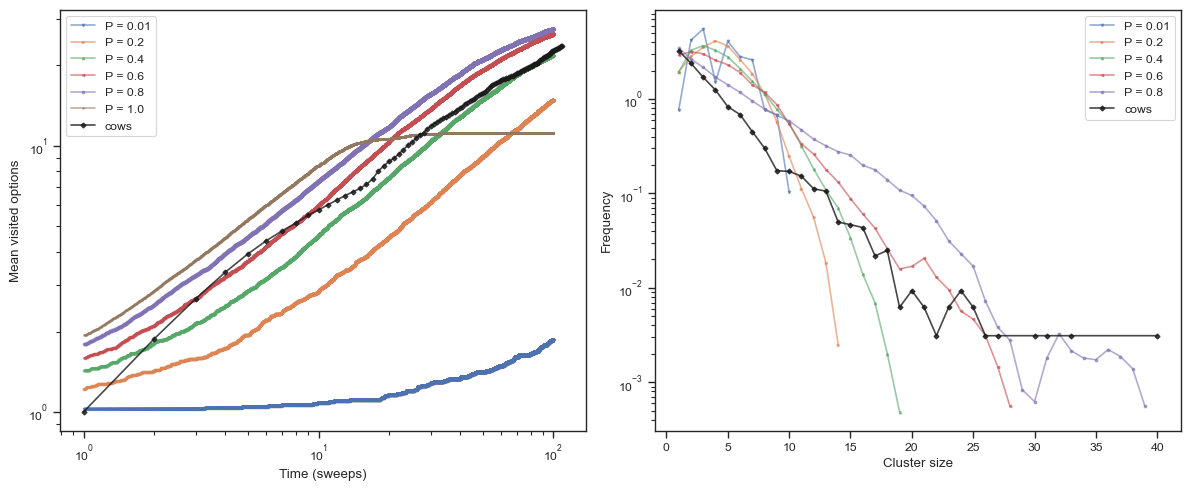

'\n# we change the amount of individuals:\ndf_list=[]\ncluster_list = []\n\nM=60\nP1=0.8\nP2=1-P1\nfor N in [30,60,90,120,180,240,300]:\n    T=100*N\n    history = voter_model(N,M,T,P1,P2)\n    df = compute_visited_sites_stats_fast(history, T, N, M)\n    df.attrs["label"]=f"N = {N}"\n    df_list.append(df)\n    cluster_list.append(compute_cluster_distribution(history, M))\n\n\nplot_visited_and_clusters(df_list, cluster_list, stat_cows, hist_cows, savepath="../Plots/Article/variable_N.pdf")\n\n\n#we change the number of clusters:\ndf_list=[]\ncluster_list = []\n\nN=60\nT=100*N\nP1=0.8\nP2=1-P1\nfor M in [30,60,90,120,180,240,300]:\n    history = voter_model(N,M,T,P1,P2)\n    df = compute_visited_sites_stats_fast(history, T, N, M)\n    df.attrs["label"]=f"M = {M}"\n    df_list.append(df)\n    cluster_list.append(compute_cluster_distribution(history, M))\n\n\nplot_visited_and_clusters(df_list, cluster_list, stat_cows, hist_cows, savepath="../Plots/Article/variable_M.pdf")\n'

In [12]:
#We change the value of the imitation parameter:
df_list=[]
cluster_list = []

N=144
M=33
T=100*N
for P1 in [0.01, 0.2, 0.4, 0.6, 0.8, 1.0]:
    P2=1-P1
    history = voter_model(N,M,T,P1,P2)
    df = compute_visited_sites_stats_fast(history, T, N, M)
    df.attrs["label"]=f"P = {P1}"
    df_list.append(df)
    if P1!=1.0:
        cluster_list.append(compute_cluster_distribution(history, M))

plot_visited_and_clusters(df_list, cluster_list, stat_cows, hist_cows, savepath="../Plots/Article/variable_P.pdf")

"""
# we change the amount of individuals:
df_list=[]
cluster_list = []

M=60
P1=0.8
P2=1-P1
for N in [30,60,90,120,180,240,300]:
    T=100*N
    history = voter_model(N,M,T,P1,P2)
    df = compute_visited_sites_stats_fast(history, T, N, M)
    df.attrs["label"]=f"N = {N}"
    df_list.append(df)
    cluster_list.append(compute_cluster_distribution(history, M))
    

plot_visited_and_clusters(df_list, cluster_list, stat_cows, hist_cows, savepath="../Plots/Article/variable_N.pdf")


#we change the number of clusters:
df_list=[]
cluster_list = []

N=60
T=100*N
P1=0.8
P2=1-P1
for M in [30,60,90,120,180,240,300]:
    history = voter_model(N,M,T,P1,P2)
    df = compute_visited_sites_stats_fast(history, T, N, M)
    df.attrs["label"]=f"M = {M}"
    df_list.append(df)
    cluster_list.append(compute_cluster_distribution(history, M))
    

plot_visited_and_clusters(df_list, cluster_list, stat_cows, hist_cows, savepath="../Plots/Article/variable_M.pdf")
"""



In [ ]:
"""
def fit_power_law(df_stats):
    # remove time_step = 0 or any zeros just in case
    df = df_stats[(df_stats["time_step"] > 0) & (df_stats["mean_clusters"] > 0)]

    x = np.log(df["time_step"]).values.reshape(-1, 1)
    y = np.log(df["mean_clusters"]).values

    model = LinearRegression()
    model.fit(x, y)
    
    alpha = model.coef_[0]
    intercept = model.intercept_

    return alpha, intercept, model

def plot_power_law_fit(df_stats, alpha, intercept, year_label, save_path=None):
    plt.figure(figsize=(8, 5))

    # data
    x = df_stats["time_step"]
    y = df_stats["mean_clusters"]

    # --- 1) Plot error bars FIRST (behind the line) ---
    plt.errorbar(
        x,
        y,
        yerr=df_stats["sd_clusters"],
        fmt='kx',
        ecolor=None,     # default
        elinewidth=1,
        capsize=2,
        alpha=0.7,
        zorder=1         # force background
    )

    # --- 2) Plot fitted line LAST (on top) ---
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = np.exp(intercept) * x_fit**alpha
    plt.plot(x_fit, y_fit, "r--", linewidth=2, zorder=10, label = fr'$\sim t^{{{alpha:.3f}}}$')  

    plt.xscale("log")
    plt.yscale("log")
    plt.legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_all_time(df_total, save_path=None):
    plt.figure(figsize=(8, 5))
    
    for df in df_total:
        x = df["time_step"]
        y = df["mean_clusters"]
    
        # --- 1) Plot error bars FIRST (behind the line) ---
        if df.attrs["label"] != "cows":
            plt.errorbar(
                x,
                y,
                yerr=df["sd_clusters"],
                fmt='x',
                ecolor=None,     # default
                elinewidth=1,
                capsize=2,
                alpha=0.5,
                zorder=1, # force background
                label = df.attrs["label"]
            )
        else:
            plt.errorbar(
                x,
                y,
                yerr=df["sd_clusters"],
                fmt='k*',
                ecolor=None,     # default
                elinewidth=1,
                capsize=2,
                alpha=0.8,
                zorder=1, # force background
                label = df.attrs["label"]
            )

    #plt.xscale("log")
    #plt.yscale("log")
    plt.legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
"""    

In [261]:
M = 33 #num_sites
N = 144 #individuals
T = 109 #nights


#Probabilities of exploring. IMPORTANT: P1+P2<=1 and both have to be positive!!
P1 = 0.34 #imitation rule
P2 = 0.6 #memory rule
P3 = 1-P2-P1 #exploration rule

history_imit = voter_model(N,M,T,0.75,0.05)
history_memo = voter_model(N,M,T,0.05,0.75)
history_sim = voter_model(N,M,T,0.34,0.6)
history_rand = voter_model(N,M,T,0.05,0.05)

imitation = compute_visited_sites_stats_fast(history_imit, T, N, M)
imitation.attrs["label"] = "imitation"
memory = compute_visited_sites_stats_fast(history_memo, T, N, M)
memory.attrs["label"] = "memory"
similar = compute_visited_sites_stats_fast(history_sim, T, N, M)
similar.attrs["label"] = "similar"
random = compute_visited_sites_stats_fast(history_rand, T, N, M)
random.attrs["label"] = "random"

df_stat=pd.read_csv("../Data/counts_night.csv")
df_stat.attrs["label"] = "cows"

df=[imitation, memory, similar, random, df_stat]
#alpha, intercept, model = fit_power_law(df_visited)
#print("Scaling exponent α =", alpha)
#print("Intercept =", intercept)

#plot_power_law_fit(df_visited, alpha, intercept, "random" , save_path=None)
#df_visited

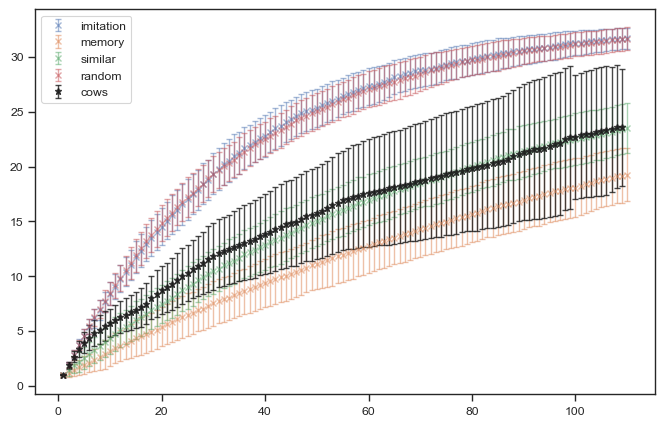

In [278]:
#plot_all_time(df, save_path="../Plots/Article/sim_run.pdf")
plot_all_time(df, save_path=None)